# chapter2.迴歸


In [ ]:
batch_n = 100
in_features = 3
out_features = 1
epoch_n = 100
learning_rate = 0.001

In [ ]:
import torch

In [ ]:
# y = 3x_1 + 5x_2 + 1x_3
x = torch.rand(batch_n, in_features)
x

tensor([[0.2701, 0.2698, 0.9741],
        [0.8930, 0.5303, 0.7067],
        [0.3040, 0.7240, 0.2673],
        [0.1833, 0.6868, 0.1470],
        [0.8036, 0.6044, 0.4760],
        [0.9703, 0.2797, 0.6281],
        [0.5485, 0.2562, 0.1682],
        [0.0232, 0.9689, 0.5485],
        [0.3622, 0.6735, 0.5679],
        [0.7688, 0.5798, 0.6548],
        [0.0790, 0.1718, 0.3011],
        [0.4312, 0.7615, 0.9775],
        [0.2916, 0.1415, 0.9279],
        [0.0115, 0.7966, 0.7349],
        [0.0872, 0.5591, 0.4972],
        [0.0305, 0.6031, 0.0343],
        [0.7557, 0.3859, 0.0046],
        [0.8056, 0.0348, 0.2325],
        [0.4471, 0.2607, 0.1382],
        [0.4037, 0.9629, 0.0987],
        [0.7024, 0.7891, 0.4882],
        [0.3600, 0.3074, 0.6823],
        [0.1439, 0.6506, 0.4016],
        [0.9279, 0.0536, 0.1441],
        [0.4534, 0.8579, 0.3427],
        [0.5445, 0.2195, 0.3951],
        [0.4407, 0.6294, 0.6952],
        [0.8141, 0.7503, 0.7128],
        [0.7401, 0.6646, 0.4088],
        [0.299

In [ ]:
c = torch.tensor([[3.0], [5.0], [1.0]])
c

tensor([[3.],
        [5.],
        [1.]])

In [ ]:
y = x.mm(c)
y = y.add(torch.rand(batch_n, out_features))
y

tensor([[3.3379],
        [7.0013],
        [5.1822],
        [4.9310],
        [6.1142],
        [5.7922],
        [3.3957],
        [5.7178],
        [5.8573],
        [6.1411],
        [1.7377],
        [6.5092],
        [3.2666],
        [5.1932],
        [3.6197],
        [3.2972],
        [4.5794],
        [3.1412],
        [3.4206],
        [6.3965],
        [6.6274],
        [3.5715],
        [4.0887],
        [3.3346],
        [6.0498],
        [3.9240],
        [5.9619],
        [7.8427],
        [6.0380],
        [6.4138],
        [7.8966],
        [4.8659],
        [7.9850],
        [6.6178],
        [8.4344],
        [6.2465],
        [6.2560],
        [3.3690],
        [6.1320],
        [4.1565],
        [3.8599],
        [4.7080],
        [7.3155],
        [6.6749],
        [3.9827],
        [2.8736],
        [7.8007],
        [1.5846],
        [4.2249],
        [6.7622],
        [4.7447],
        [6.4767],
        [7.1554],
        [2.9239],
        [4.0378],
        [5

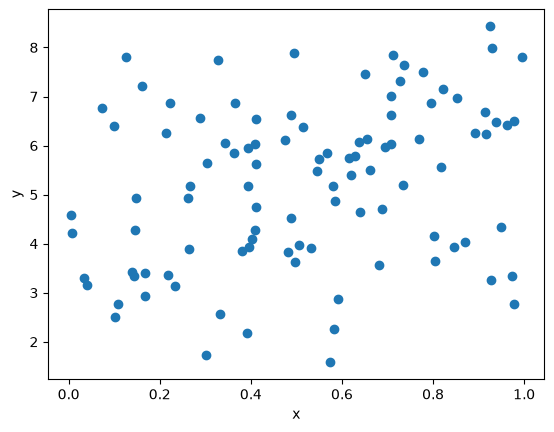

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(x[:, 2], y)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [ ]:
w = torch.rand(
    in_features,
    out_features,
)
w

tensor([[0.4132],
        [0.0310],
        [0.6365]])

### 土法煉鋼

In [ ]:
for epoch in range(epoch_n):
    y_pred = x.mm(w)
    loss = (y_pred - y).pow(2).sum()
    print("Epoch:{}, Loss:{:.4f}".format(epoch, loss))

    grad_y_pred = 2 * (y_pred - y)
    grad_w = x.t().mm(grad_y_pred)

    w -= learning_rate * grad_w

Epoch:0, Loss:2412.8877
Epoch:1, Loss:1647.2502
Epoch:2, Loss:1130.5701
Epoch:3, Loss:781.7620
Epoch:4, Loss:546.1539
Epoch:5, Loss:386.8823
Epoch:6, Loss:279.0916
Epoch:7, Loss:206.0226
Epoch:8, Loss:156.3751
Epoch:9, Loss:122.5295
Epoch:10, Loss:99.3481
Epoch:11, Loss:83.3664
Epoch:12, Loss:72.2484
Epoch:13, Loss:64.4187
Epoch:14, Loss:58.8147
Epoch:15, Loss:54.7200
Epoch:16, Loss:51.6511
Epoch:17, Loss:49.2819
Epoch:18, Loss:47.3923
Epoch:19, Loss:45.8336
Epoch:20, Loss:44.5056
Epoch:21, Loss:43.3403
Epoch:22, Loss:42.2917
Epoch:23, Loss:41.3286
Epoch:24, Loss:40.4299
Epoch:25, Loss:39.5811
Epoch:26, Loss:38.7723
Epoch:27, Loss:37.9966
Epoch:28, Loss:37.2492
Epoch:29, Loss:36.5267
Epoch:30, Loss:35.8268
Epoch:31, Loss:35.1476
Epoch:32, Loss:34.4878
Epoch:33, Loss:33.8463
Epoch:34, Loss:33.2223
Epoch:35, Loss:32.6150
Epoch:36, Loss:32.0240
Epoch:37, Loss:31.4486
Epoch:38, Loss:30.8883
Epoch:39, Loss:30.3427
Epoch:40, Loss:29.8114
Epoch:41, Loss:29.2940
Epoch:42, Loss:28.7902
Epoch:43

In [ ]:
w

tensor([[3.2954],
        [4.5853],
        [1.9991]])

### Auto grad

In [ ]:
from torch.autograd import Variable

In [ ]:
Vx = Variable(x, requires_grad=False)
Vy = Variable(y, requires_grad=False)
Vw = Variable(torch.rand(in_features, out_features), requires_grad=True)

In [ ]:
for epoch in range(epoch_n):
    y_pred= Vx.mm(Vw)
    loss = (y_pred- Vy).pow(2).sum()
    print("Epoch:{}, Loss:{:.4f}".format(epoch, loss))

    loss.backward()

    Vw.data -= learning_rate * Vw.grad.data

    Vw.grad.data.zero_()

Epoch:0, Loss:2531.0178
Epoch:1, Loss:1719.1288
Epoch:2, Loss:1171.4657
Epoch:3, Loss:801.9645
Epoch:4, Loss:552.5959
Epoch:5, Loss:384.2333
Epoch:6, Loss:270.4951
Epoch:7, Loss:193.5935
Epoch:8, Loss:141.5346
Epoch:9, Loss:106.2314
Epoch:10, Loss:82.2311
Epoch:11, Loss:65.8569
Epoch:12, Loss:54.6297
Epoch:13, Loss:46.8778
Epoch:14, Loss:41.4738
Epoch:15, Loss:37.6575
Epoch:16, Loss:34.9163
Epoch:17, Loss:32.9043
Epoch:18, Loss:31.3882
Epoch:19, Loss:30.2107
Epoch:20, Loss:29.2655
Epoch:21, Loss:28.4809
Epoch:22, Loss:27.8084
Epoch:23, Loss:27.2153
Epoch:24, Loss:26.6793
Epoch:25, Loss:26.1853
Epoch:26, Loss:25.7232
Epoch:27, Loss:25.2859
Epoch:28, Loss:24.8686
Epoch:29, Loss:24.4680
Epoch:30, Loss:24.0818
Epoch:31, Loss:23.7082
Epoch:32, Loss:23.3462
Epoch:33, Loss:22.9948
Epoch:34, Loss:22.6534
Epoch:35, Loss:22.3215
Epoch:36, Loss:21.9985
Epoch:37, Loss:21.6842
Epoch:38, Loss:21.3783
Epoch:39, Loss:21.0805
Epoch:40, Loss:20.7905
Epoch:41, Loss:20.5081
Epoch:42, Loss:20.2331
Epoch:43

In [ ]:
Vw.data

tensor([[3.2910],
        [4.7305],
        [1.8511]])

### nn.Module


In [ ]:
import torch.nn as nn

In [ ]:
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()

    def forward(self, x, w):
        y_pred= x.mm(w)
        return y_pred

    def backward(self):
        pass

In [ ]:
model = Model()
Vw = Variable(torch.rand(in_features, out_features), requires_grad=True)

In [ ]:
for epoch in range(epoch_n):
    y_pred= model(Vx, Vw)
    loss = (y_pred- Vy).pow(2).sum()
    print("Epoch:{}, Loss:{:.4f}".format(epoch, loss))

    loss.backward()

    Vw.data -= learning_rate * Vw.grad.data

    Vw.grad.data.zero_()

Epoch:0, Loss:2142.2905
Epoch:1, Loss:1463.2181
Epoch:2, Loss:1004.9402
Epoch:3, Loss:695.5448
Epoch:4, Loss:486.5449
Epoch:5, Loss:345.2473
Epoch:6, Loss:249.6082
Epoch:7, Loss:184.7645
Epoch:8, Loss:140.6941
Epoch:9, Loss:110.6396
Epoch:10, Loss:90.0443
Epoch:11, Loss:75.8357
Epoch:12, Loss:65.9419
Epoch:13, Loss:58.9657
Epoch:14, Loss:53.9649
Epoch:15, Loss:50.3037
Epoch:16, Loss:47.5536
Epoch:17, Loss:45.4251
Epoch:18, Loss:43.7231
Epoch:19, Loss:42.3157
Epoch:20, Loss:41.1138
Epoch:21, Loss:40.0572
Epoch:22, Loss:39.1051
Epoch:23, Loss:38.2297
Epoch:24, Loss:37.4123
Epoch:25, Loss:36.6400
Epoch:26, Loss:35.9040
Epoch:27, Loss:35.1981
Epoch:28, Loss:34.5180
Epoch:29, Loss:33.8608
Epoch:30, Loss:33.2243
Epoch:31, Loss:32.6068
Epoch:32, Loss:32.0071
Epoch:33, Loss:31.4243
Epoch:34, Loss:30.8576
Epoch:35, Loss:30.3063
Epoch:36, Loss:29.7699
Epoch:37, Loss:29.2478
Epoch:38, Loss:28.7398
Epoch:39, Loss:28.2452
Epoch:40, Loss:27.7638
Epoch:41, Loss:27.2951
Epoch:42, Loss:26.8388
Epoch:43

In [ ]:
Vw.data

tensor([[3.2246],
        [4.6592],
        [1.9879]])

### Loss Function


In [ ]:
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.linear = nn.Linear(in_features, out_features, False)

    def forward(self, x):
        y_pred= self.linear(x)
        return y_pred

    def backward(self):
        pass

In [ ]:
model = Model()
loss_fn = nn.MSELoss()
print(model)

Model(
  (linear): Linear(in_features=3, out_features=1, bias=False)
)


In [ ]:
for epoch in range(epoch_n * 100):
    y_pred = model(x)
    loss = loss_fn(y_pred, y)
    if epoch % 100 == 0:
        print("Epoch:{}, Loss:{:.4f}".format(epoch, loss))

    model.zero_grad()
    loss.backward()

    for param in model.parameters():
        param.data -= learning_rate * param.grad.data

Epoch:0, Loss:31.9932
Epoch:100, Loss:22.4886
Epoch:200, Loss:15.8421
Epoch:300, Loss:11.1936
Epoch:400, Loss:7.9419
Epoch:500, Loss:5.6666
Epoch:600, Loss:4.0738
Epoch:700, Loss:2.9583
Epoch:800, Loss:2.1764
Epoch:900, Loss:1.6279
Epoch:1000, Loss:1.2424
Epoch:1100, Loss:0.9710
Epoch:1200, Loss:0.7794
Epoch:1300, Loss:0.6437
Epoch:1400, Loss:0.5470
Epoch:1500, Loss:0.4777
Epoch:1600, Loss:0.4275
Epoch:1700, Loss:0.3908
Epoch:1800, Loss:0.3636
Epoch:1900, Loss:0.3429
Epoch:2000, Loss:0.3270
Epoch:2100, Loss:0.3144
Epoch:2200, Loss:0.3041
Epoch:2300, Loss:0.2955
Epoch:2400, Loss:0.2881
Epoch:2500, Loss:0.2816
Epoch:2600, Loss:0.2758
Epoch:2700, Loss:0.2704
Epoch:2800, Loss:0.2655
Epoch:2900, Loss:0.2608
Epoch:3000, Loss:0.2563
Epoch:3100, Loss:0.2521
Epoch:3200, Loss:0.2480
Epoch:3300, Loss:0.2441
Epoch:3400, Loss:0.2403
Epoch:3500, Loss:0.2366
Epoch:3600, Loss:0.2330
Epoch:3700, Loss:0.2295
Epoch:3800, Loss:0.2261
Epoch:3900, Loss:0.2228
Epoch:4000, Loss:0.2196
Epoch:4100, Loss:0.2165


In [ ]:
for param in model.parameters():
    print(param.data)

tensor([[3.2814, 4.7125, 1.8788]])


### Optimizer

In [ ]:
model = Model()

In [ ]:
for param in model.parameters():
    print(param.data)

tensor([[-0.5587,  0.4156,  0.3977]])


In [ ]:
import torch.optim as opt

In [ ]:
optimizer = opt.SGD(model.parameters(), lr=learning_rate)

In [ ]:
for epoch in range(epoch_n * 100):
    y_pred= model(x)
    loss = loss_fn(y_pred, y)
    if epoch % 100 == 0:
        print("Epoch:{}, Loss:{:.4f}".format(epoch, loss))

    model.zero_grad()
    loss.backward()
    optimizer.step()

Epoch:0, Loss:28.1845
Epoch:100, Loss:19.8695
Epoch:200, Loss:14.0533
Epoch:300, Loss:9.9840
Epoch:400, Loss:7.1359
Epoch:500, Loss:5.1416
Epoch:600, Loss:3.7442
Epoch:700, Loss:2.7641
Epoch:800, Loss:2.0758
Epoch:900, Loss:1.5916
Epoch:1000, Loss:1.2502
Epoch:1100, Loss:1.0086
Epoch:1200, Loss:0.8369
Epoch:1300, Loss:0.7141
Epoch:1400, Loss:0.6256
Epoch:1500, Loss:0.5612
Epoch:1600, Loss:0.5136
Epoch:1700, Loss:0.4778
Epoch:1800, Loss:0.4505
Epoch:1900, Loss:0.4290
Epoch:2000, Loss:0.4118
Epoch:2100, Loss:0.3975
Epoch:2200, Loss:0.3854
Epoch:2300, Loss:0.3748
Epoch:2400, Loss:0.3654
Epoch:2500, Loss:0.3569
Epoch:2600, Loss:0.3490
Epoch:2700, Loss:0.3416
Epoch:2800, Loss:0.3346
Epoch:2900, Loss:0.3280
Epoch:3000, Loss:0.3216
Epoch:3100, Loss:0.3155
Epoch:3200, Loss:0.3096
Epoch:3300, Loss:0.3039
Epoch:3400, Loss:0.2984
Epoch:3500, Loss:0.2930
Epoch:3600, Loss:0.2878
Epoch:3700, Loss:0.2827
Epoch:3800, Loss:0.2778
Epoch:3900, Loss:0.2730
Epoch:4000, Loss:0.2684
Epoch:4100, Loss:0.2639
E

In [ ]:
for param in model.parameters():
    print(param.data)

tensor([[3.1763, 4.7123, 1.9774]])


In [ ]:
import numpy as np

In [ ]:
npy = y.numpy()
bins = np.array([npy.mean()])
inds = np.digitize(npy, bins)
cy = torch.from_numpy(inds)
cy = cy.float()
cy

tensor([[0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
      

In [ ]:
Vx = Variable(x, requires_grad=False)
Vy = Variable(cy, requires_grad=False)
Vw = Variable(torch.rand(in_features, out_features), requires_grad=True)

In [ ]:
for epoch in range(epoch_n * 1000):
    y_pred = torch.sigmoid(Vx.mm(Vw))
    loss = (
        -1.0 * (Vy * torch.log10(y_pred) + (1.0 - Vy) * torch.log10(1.0 - y_pred))
    ).mean()

    if epoch % 1000 == 0:
        print("Epoch:{}, Loss:{:.4f}".format(epoch, loss))

    loss.backward()

    Vw.data -= learning_rate * Vw.grad.data

    Vw.grad.data.zero_()

Epoch:0, Loss:0.2920
Epoch:1000, Loss:0.2911
Epoch:2000, Loss:0.2902
Epoch:3000, Loss:0.2894
Epoch:4000, Loss:0.2887
Epoch:5000, Loss:0.2880
Epoch:6000, Loss:0.2874
Epoch:7000, Loss:0.2868
Epoch:8000, Loss:0.2863
Epoch:9000, Loss:0.2858
Epoch:10000, Loss:0.2853
Epoch:11000, Loss:0.2849
Epoch:12000, Loss:0.2844
Epoch:13000, Loss:0.2840
Epoch:14000, Loss:0.2836
Epoch:15000, Loss:0.2832
Epoch:16000, Loss:0.2829
Epoch:17000, Loss:0.2825
Epoch:18000, Loss:0.2822
Epoch:19000, Loss:0.2818
Epoch:20000, Loss:0.2815
Epoch:21000, Loss:0.2811
Epoch:22000, Loss:0.2808
Epoch:23000, Loss:0.2805
Epoch:24000, Loss:0.2802
Epoch:25000, Loss:0.2799
Epoch:26000, Loss:0.2796
Epoch:27000, Loss:0.2793
Epoch:28000, Loss:0.2790
Epoch:29000, Loss:0.2787
Epoch:30000, Loss:0.2785
Epoch:31000, Loss:0.2782
Epoch:32000, Loss:0.2779
Epoch:33000, Loss:0.2777
Epoch:34000, Loss:0.2774
Epoch:35000, Loss:0.2771
Epoch:36000, Loss:0.2769
Epoch:37000, Loss:0.2766
Epoch:38000, Loss:0.2764
Epoch:39000, Loss:0.2762
Epoch:40000, 

In [ ]:
Vw

tensor([[ 0.0702],
        [ 1.3634],
        [-0.4700]], requires_grad=True)

### torch.nn


In [ ]:
class LogisticRegression(nn.Module):
    def __init__(self):
        super(LogisticRegression, self).__init__()

    def forward(self, x, w):
        y_pred = torch.sigmoid(x.mm(w))
        return y_pred

In [ ]:
model = LogisticRegression()
Vw = torch.rand(in_features, out_features, requires_grad=True)

In [ ]:
for epoch in range(epoch_n * 1000):
    y_pred = model(Vx, Vw)
    loss = (
        -1.0 * (Vy * torch.log10(y_pred) + (1.0 - Vy) * torch.log10(1.0 - y_pred))
    ).mean()

    if epoch % 1000 == 0:
        print("Epoch:{}, Loss:{:.4f}".format(epoch, loss))

    loss.backward()

    Vw.data -= learning_rate * Vw.grad.data

    Vw.grad.data.zero_()

Epoch:0, Loss:0.2850
Epoch:1000, Loss:0.2841
Epoch:2000, Loss:0.2832
Epoch:3000, Loss:0.2824
Epoch:4000, Loss:0.2817
Epoch:5000, Loss:0.2810
Epoch:6000, Loss:0.2804
Epoch:7000, Loss:0.2799
Epoch:8000, Loss:0.2794
Epoch:9000, Loss:0.2790
Epoch:10000, Loss:0.2785
Epoch:11000, Loss:0.2781
Epoch:12000, Loss:0.2778
Epoch:13000, Loss:0.2774
Epoch:14000, Loss:0.2771
Epoch:15000, Loss:0.2768
Epoch:16000, Loss:0.2765
Epoch:17000, Loss:0.2762
Epoch:18000, Loss:0.2759
Epoch:19000, Loss:0.2757
Epoch:20000, Loss:0.2754
Epoch:21000, Loss:0.2752
Epoch:22000, Loss:0.2749
Epoch:23000, Loss:0.2747
Epoch:24000, Loss:0.2745
Epoch:25000, Loss:0.2743
Epoch:26000, Loss:0.2740
Epoch:27000, Loss:0.2738
Epoch:28000, Loss:0.2736
Epoch:29000, Loss:0.2734
Epoch:30000, Loss:0.2732
Epoch:31000, Loss:0.2730
Epoch:32000, Loss:0.2728
Epoch:33000, Loss:0.2726
Epoch:34000, Loss:0.2724
Epoch:35000, Loss:0.2723
Epoch:36000, Loss:0.2721
Epoch:37000, Loss:0.2719
Epoch:38000, Loss:0.2717
Epoch:39000, Loss:0.2716
Epoch:40000, 

In [ ]:
class LogisticRegression(nn.Module):
    def __init__(self):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(in_features, out_features, False)

    def forward(self, x):
        y_pred = torch.sigmoid(self.linear(x))
        return y_pred

In [ ]:
model = LogisticRegression()
loss_fn = nn.BCELoss()
print(model)

LogisticRegression(
  (linear): Linear(in_features=3, out_features=1, bias=False)
)


In [ ]:
for epoch in range(epoch_n * 1000):
    y_pred = model(Vx)
    loss = loss_fn(y_pred, Vy)

    if epoch % 1000 == 0:
        print("Epoch:{}, Loss:{:.4f}".format(epoch, loss))

    model.zero_grad()
    loss.backward()

    for param in model.parameters():
        param.data -= learning_rate * param.grad.data

Epoch:0, Loss:0.6482
Epoch:1000, Loss:0.6452
Epoch:2000, Loss:0.6428
Epoch:3000, Loss:0.6408
Epoch:4000, Loss:0.6390
Epoch:5000, Loss:0.6374
Epoch:6000, Loss:0.6360
Epoch:7000, Loss:0.6346
Epoch:8000, Loss:0.6333
Epoch:9000, Loss:0.6321
Epoch:10000, Loss:0.6310
Epoch:11000, Loss:0.6299
Epoch:12000, Loss:0.6288
Epoch:13000, Loss:0.6278
Epoch:14000, Loss:0.6268
Epoch:15000, Loss:0.6258
Epoch:16000, Loss:0.6249
Epoch:17000, Loss:0.6240
Epoch:18000, Loss:0.6232
Epoch:19000, Loss:0.6223
Epoch:20000, Loss:0.6215
Epoch:21000, Loss:0.6207
Epoch:22000, Loss:0.6199
Epoch:23000, Loss:0.6192
Epoch:24000, Loss:0.6185
Epoch:25000, Loss:0.6178
Epoch:26000, Loss:0.6171
Epoch:27000, Loss:0.6165
Epoch:28000, Loss:0.6158
Epoch:29000, Loss:0.6152
Epoch:30000, Loss:0.6146
Epoch:31000, Loss:0.6141
Epoch:32000, Loss:0.6135
Epoch:33000, Loss:0.6130
Epoch:34000, Loss:0.6124
Epoch:35000, Loss:0.6119
Epoch:36000, Loss:0.6114
Epoch:37000, Loss:0.6109
Epoch:38000, Loss:0.6105
Epoch:39000, Loss:0.6100
Epoch:40000, 

In [ ]:
for param in model.parameters():
    print(param.data)

tensor([[-0.1491,  2.1536, -1.0391]])


In [ ]:
model = LogisticRegression()
optimizer = opt.SGD(model.parameters(), lr=learning_rate)

In [ ]:
for epoch in range(epoch_n * 1000):
    y_pred = model(Vx)
    loss = loss_fn(y_pred, Vy)

    if epoch % 1000 == 0:
        print("Epoch:{}, Loss:{:.4f}".format(epoch, loss))

    model.zero_grad()
    loss.backward()
    optimizer.step()

Epoch:0, Loss:0.6586
Epoch:1000, Loss:0.6558
Epoch:2000, Loss:0.6534
Epoch:3000, Loss:0.6513
Epoch:4000, Loss:0.6493
Epoch:5000, Loss:0.6475
Epoch:6000, Loss:0.6458
Epoch:7000, Loss:0.6442
Epoch:8000, Loss:0.6427
Epoch:9000, Loss:0.6412
Epoch:10000, Loss:0.6398
Epoch:11000, Loss:0.6384
Epoch:12000, Loss:0.6371
Epoch:13000, Loss:0.6359
Epoch:14000, Loss:0.6347
Epoch:15000, Loss:0.6335
Epoch:16000, Loss:0.6323
Epoch:17000, Loss:0.6312
Epoch:18000, Loss:0.6302
Epoch:19000, Loss:0.6291
Epoch:20000, Loss:0.6281
Epoch:21000, Loss:0.6271
Epoch:22000, Loss:0.6262
Epoch:23000, Loss:0.6253
Epoch:24000, Loss:0.6244
Epoch:25000, Loss:0.6235
Epoch:26000, Loss:0.6227
Epoch:27000, Loss:0.6219
Epoch:28000, Loss:0.6211
Epoch:29000, Loss:0.6204
Epoch:30000, Loss:0.6196
Epoch:31000, Loss:0.6189
Epoch:32000, Loss:0.6182
Epoch:33000, Loss:0.6175
Epoch:34000, Loss:0.6169
Epoch:35000, Loss:0.6163
Epoch:36000, Loss:0.6156
Epoch:37000, Loss:0.6151
Epoch:38000, Loss:0.6145
Epoch:39000, Loss:0.6139
Epoch:40000, 

In [ ]:
for param in model.parameters():
    print(param.data)

tensor([[-0.1672,  2.1000, -0.9708]])
